# Teacher model

### Check speechbrain library

In [16]:
import sys
print("Interpreter:", sys.executable)

try:
    import speechbrain
    print("SpeechBrain imported. Version:", speechbrain.__version__)
    from speechbrain.inference.classifiers import EncoderClassifier
    print("EncoderClassifier from inference available")
except Exception as e:
    print("Error:", type(e).__name__, e)

Interpreter: C:\Users\Svetozar\PycharmProjects\ASTRA_voiceprint\.venv\Scripts\python.exe
SpeechBrain imported. Version: 1.1.1
EncoderClassifier from inference available


### Disable display of warnings

In [17]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message=".*weights_only=False.*")

### Establishing the teacher's baseline

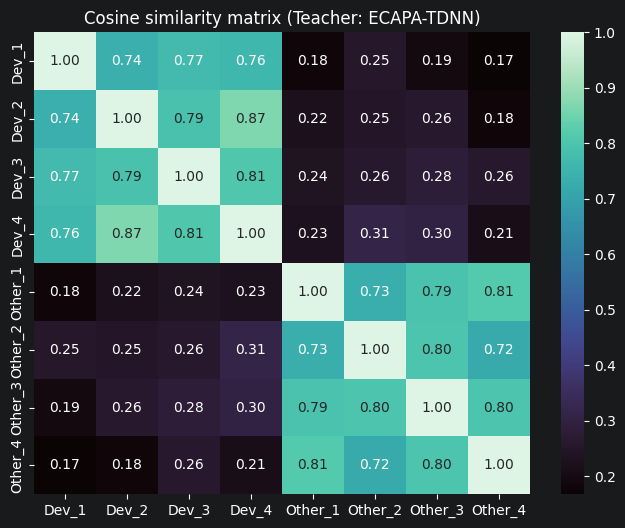

In [18]:
import os
import sys

if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

# Clearing the frozen speechbrain modules from the kernel memory
for mod in list(sys.modules.keys()):
    if "speechbrain" in mod:
        del sys.modules[mod]

import torch
import torchaudio
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from speechbrain.inference.classifiers import EncoderClassifier
from speechbrain.utils.fetching import LocalStrategy

dev_dir = os.path.abspath("data/raw/speakers/baseline/developer")
dist_dir = os.path.abspath("data/raw/speakers/baseline/speakers")

dev_files = [os.path.join(dev_dir, f) for f in os.listdir(dev_dir) if f.lower().endswith(".wav")]
dist_files = [os.path.join(dist_dir, f) for f in os.listdir(dist_dir) if f.lower().endswith(".wav")]

device = "cuda:0" if torch.cuda.is_available() else "cpu"

classifier = EncoderClassifier.from_hparams(
    source="models/teacher/ecapa_voxceleb",
    savedir="models/teacher/ecapa_voxceleb",
    run_opts={"device": device},
    local_strategy=LocalStrategy.COPY
)

def get_embedding(wav_path):
    signal, fs = torchaudio.load(wav_path)


    if signal.shape[0] > 1:
        signal = torch.mean(signal, dim=0, keepdim=True)


    if fs != 16000:
        signal = torchaudio.transforms.Resample(fs, 16000)(signal)

    with torch.no_grad():
        emb = classifier.encode_batch(signal.to(device))
        emb = torch.nn.functional.normalize(emb, dim=-1).squeeze().flatten().cpu().numpy()

    return emb

all_files = dev_files + dist_files
labels = [f"Dev_{i+1}" for i in range(len(dev_files))] + [f"Other_{i+1}" for i in range(len(dist_files))]

embeddings = [get_embedding(f) for f in all_files]

matrix = np.zeros((len(all_files), len(all_files)))
for i in range(len(all_files)):
    for j in range(len(all_files)):
        matrix[i, j] = float(np.dot(embeddings[i], embeddings[j]))

plt.figure(figsize=(8, 6))
sns.heatmap(matrix, xticklabels=labels, yticklabels=labels, annot=True, cmap="mako", fmt=".2f")
plt.title("Cosine similarity matrix (Teacher: ECAPA-TDNN)")
plt.show()

### Full Validation on 160 Pairs (EER, Distributions & ROC Curve)

Teacher Architecture: ECAPA-TDNN (192-dim)
Validating on: 200 pairs
Equal Error Rate (EER): 2.00%
Optimal Decision Threshold: 0.411


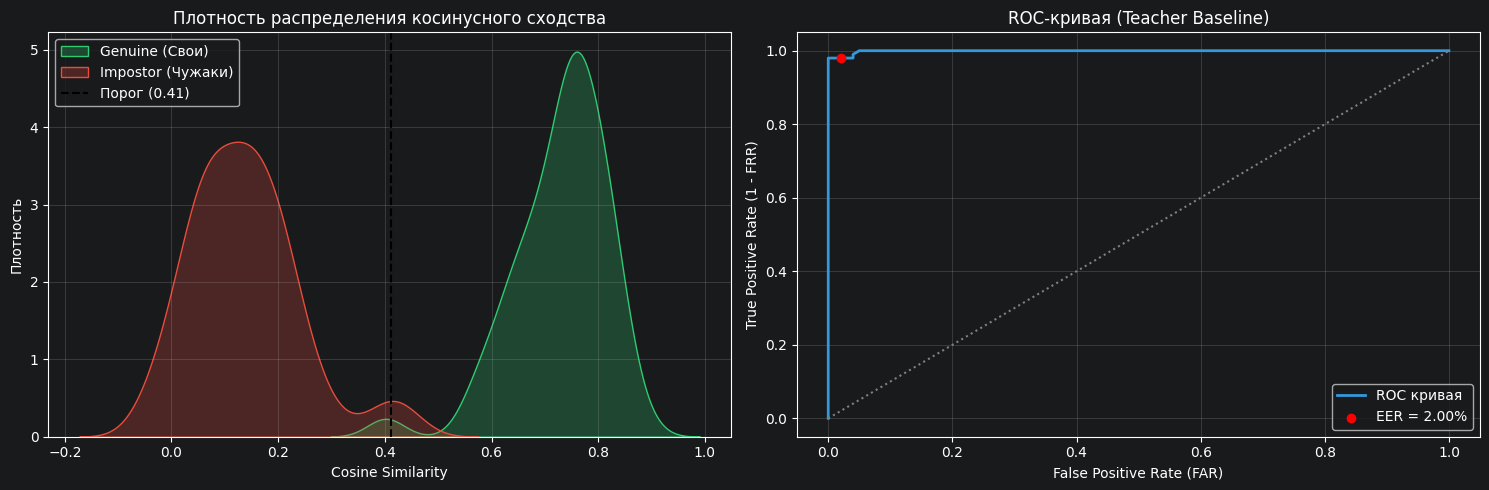

In [19]:
import os
import csv
import warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torchaudio

warnings.filterwarnings("ignore")

if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

manifest_path = os.path.abspath("data/manifest/val_pairs.csv")
if not os.path.exists(manifest_path):
    raise FileNotFoundError(f"Файл не найден по пути: {manifest_path}")

device = "cuda:0" if torch.cuda.is_available() else "cpu"

if "classifier" not in globals():
    from speechbrain.inference.classifiers import EncoderClassifier
    from speechbrain.utils.fetching import LocalStrategy

    classifier = EncoderClassifier.from_hparams(
        source="models/teacher/ecapa_voxceleb",
        savedir="models/teacher/ecapa_voxceleb",
        run_opts={"device": device},
        local_strategy=LocalStrategy.COPY
    )

def extract_embedding(wav_path):
    sig, fs = torchaudio.load(wav_path)
    if sig.shape[0] > 1:
        sig = torch.mean(sig, dim=0, keepdim=True)
    if fs != 16000:
        sig = torchaudio.transforms.Resample(fs, 16000)(sig)
    with torch.no_grad():
        emb = classifier.encode_batch(sig.to(device))
        emb = torch.nn.functional.normalize(emb, dim=-1).squeeze().flatten().cpu().numpy()
    return emb

pairs = []
with open(manifest_path, "r", encoding="utf-8") as f:
    reader = csv.DictReader(f)
    for row in reader:
        pairs.append((row["path1"], row["path2"], int(row["label"])))

cache = {}
scores = []
labels = []

for p1, p2, label in pairs:
    if p1 not in cache:
        cache[p1] = extract_embedding(p1)
    if p2 not in cache:
        cache[p2] = extract_embedding(p2)

    sim = float(np.dot(cache[p1], cache[p2]))
    scores.append(sim)
    labels.append(label)

scores = np.array(scores)
labels = np.array(labels)

thresholds = np.linspace(-0.2, 1.0, 1000)
far_list = []
frr_list = []

for t in thresholds:
    far = np.mean(scores[labels == 0] >= t)
    frr = np.mean(scores[labels == 1] < t)
    far_list.append(far)
    frr_list.append(frr)

far_arr = np.array(far_list)
frr_arr = np.array(frr_list)
idx_eer = np.nanargmin(np.abs(far_arr - frr_arr))
eer = (far_arr[idx_eer] + frr_arr[idx_eer]) / 2.0
best_threshold = thresholds[idx_eer]

print(f"Teacher Architecture: ECAPA-TDNN (192-dim)")
print(f"Validating on: {len(pairs)} pairs")
print(f"Equal Error Rate (EER): {eer * 100:.2f}%")
print(f"Optimal Decision Threshold: {best_threshold:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.kdeplot(scores[labels == 1], ax=axes[0], label="Genuine (Свои)", fill=True, color="#2ecc71")
sns.kdeplot(scores[labels == 0], ax=axes[0], label="Impostor (Чужаки)", fill=True, color="#e74c3c")
axes[0].axvline(best_threshold, color="black", linestyle="--", label=f"Порог ({best_threshold:.2f})")
axes[0].set_title("Плотность распределения косинусного сходства")
axes[0].set_xlabel("Cosine Similarity")
axes[0].set_ylabel("Плотность")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

tpr = 1.0 - frr_arr
axes[1].plot(far_arr, tpr, color="#3498db", lw=2, label="ROC кривая")
axes[1].plot([0, 1], [0, 1], color="gray", linestyle=":")
axes[1].scatter([far_arr[idx_eer]], [tpr[idx_eer]], color="red", zorder=5, label=f"EER = {eer * 100:.2f}%")
axes[1].set_title("ROC-кривая (Teacher Baseline)")
axes[1].set_xlabel("False Positive Rate (FAR)")
axes[1].set_ylabel("True Positive Rate (1 - FRR)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()